## Table of Contents

1. [Project Overview](#1-project-overview)
2. [Data Engineering](#2-data-engineering)
3. [Data Structure](#3-data-structure)
4. [Compression Target](#4-compression-target)
5. [Compression Evolution](#5-compression-evolution)
6. [Modeling Results](#6-modeling-results)
7. [Sequential Modeling Insight](#7-sequential-modeling-insight)
8. [Interpretation](#8-interpretation)

# 1. Project Overview

## Reasoning Under Compression

This notebook summarizes the main analysis developed in this repository.

The project studies whether the compressibility of large language model reasoning traces can be measured and predicted. The central object of analysis is the chain-of-thought style reasoning trace: a generated sequence of intermediate reasoning blocks, each paired with a compressed summary or “memento.”

The empirical question is:

**Can we predict which parts of a reasoning trace are highly compressible?**

This question matters because long reasoning traces are expensive to store, transmit, and reuse as context. If compressibility is predictable, then future systems may be able to manage reasoning state more efficiently by identifying which parts of a trace contain redundant scaffolding and which parts carry less compressible information.

## Research Context

This project is motivated by three strands of recent LLM research.

First, chain-of-thought prompting showed that intermediate reasoning steps can improve model performance on arithmetic, commonsense, and symbolic reasoning tasks. This made reasoning traces an important object of analysis rather than just incidental model output.

Second, work on chain-of-thought compression studies whether long reasoning traces can be shortened without losing their usefulness. This introduces a practical tension between reasoning quality and inference cost.

Third, the MEMENTO framework proposes managing long reasoning by segmenting traces into blocks and compressing each block into a compact intermediate state. The OpenMementos dataset provides a natural empirical setting for studying this process.

## Dataset

The analysis uses the OpenMementos dataset from Hugging Face:

`microsoft/OpenMementos`

Each example contains:

- a `problem`
- a model `response`
- metadata such as `domain`, `source`, and `difficulty`

The response contains a hidden reasoning section marked by `<think>...</think>`. Inside this section, reasoning is segmented into repeated block-summary pairs:

`<|block_start|> ... <|block_end|>`

`<|summary_start|> ... <|summary_end|>`

The final answer appears after the thinking section.

This structure allows the dataset to be represented in two complementary ways:

- a trace-level table, where each row is one full reasoning trace
- a block-level table, where each row is one reasoning block and its corresponding summary

## Modeling Questions

The project studies compressibility at several levels.

1. **Block-level compression**

   Given a reasoning block and related metadata, predict whether its summary will be highly compressed.

2. **Trace-level compression**

   Given only the original problem and metadata, predict whether the full reasoning trace will be highly compressible.

3. **Sequential compression**

   Given the problem, the current reasoning block, and prior compression history within the trace, predict whether the current summary will be highly compressed.

These tasks move from static tabular prediction toward a more realistic online setting, where compression decisions are made as reasoning unfolds.

## Compression Target

The main block-level compression metric is:

`summary_to_block_token_ratio = summary_tokens / block_tokens`

Lower values indicate stronger compression because the summary contains fewer tokens relative to the original reasoning block.

The binary target is:

`high_token_compression = 1`

when a block falls in the lowest quartile of `summary_to_block_token_ratio`.

A separate trace-level target is defined analogously using the total summary-to-block token ratio across all blocks in a trace.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("..").resolve()))

from src.reasoning_compression.features import (
    count_share_table,
    format_describe,
    latest_feature_build_dir,
    normalize_difficulty,
)

# 2. Data Engineering

The raw OpenMementos dataset is streamed from Hugging Face and transformed into local engineered parquet files.

The repository does not store the raw dataset or generated parquet files in Git. Instead, the data engineering notebooks define a reproducible process that:

1. streams the dataset,
2. parses each response into reasoning blocks and summaries,
3. computes token-based compression features,
4. creates block-level and trace-level targets,
5. saves optimized local parquet files under the ignored `data/` directory.

The local parquet files are used by the modeling notebooks to avoid repeatedly streaming and tokenizing the full dataset.

## Engineered Tables

The full feature build produces two main tables.

`df_model_traces` is the trace-level table:

- one row per original problem-response pair
- includes problem features, response-level features, block counts, and trace-level compression targets

`df_model_blocks` is the block-level table:

- one row per `(reasoning block, summary)` pair
- includes problem features, block-position features, block and summary token counts, compression ratios, and the block-level target

The relationship is one-to-many:

`one trace -> many block-summary rows`

In [ ]:
FULL_BUILD_DIR = latest_feature_build_dir(Path("../data/full_feature_builds"))

df_model_blocks = pd.read_parquet(
    FULL_BUILD_DIR / "blocks_features_full_labeled.parquet"
)
df_model_blocks["difficulty"] = df_model_blocks["difficulty"].map(
    normalize_difficulty
)

df_model_traces = pd.read_parquet(
    FULL_BUILD_DIR / "traces_features_full_labeled.parquet"
)
df_model_traces["difficulty"] = df_model_traces["difficulty"].map(
    normalize_difficulty
)

print(f"Trace-level table: {df_model_traces.shape[0]:,} rows and {df_model_traces.shape[1]} columns")
print(f"Block-level table: {df_model_blocks.shape[0]:,} rows and {df_model_blocks.shape[1]} columns")

## Table Previews

The trace-level table summarizes each full reasoning trace. The block-level table represents each local compression event within a trace.

In [4]:
df_model_traces.head(1)

,trace_id,domain,source,difficulty,problem_chars,problem_tokens,problem_math_symbol_share,problem_has_multiple_choice,problem_has_code_fence,problem_question_mark_count,...,n_blocks,n_summaries,block_summary_delta,trace_block_tokens,trace_summary_tokens,trace_mean_summary_to_block_token_ratio,trace_median_summary_to_block_token_ratio,trace_high_compression_share,trace_total_summary_to_block_token_ratio,trace_high_token_compression
0,0,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,0,...,7,7,0,3267,898,0.29785,0.303896,0.0,0.27487,0


In [8]:
df_model_blocks.head(10)

,trace_id,block_index,domain,source,difficulty,problem_chars,problem_tokens,problem_math_symbol_share,problem_has_multiple_choice,problem_has_code_fence,...,relative_block_position,block_chars,summary_chars,block_tokens,summary_tokens,summary_to_block_char_ratio,summary_to_block_token_ratio,char_compression_savings,token_compression_savings,high_token_compression
0,0,0,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.000000,809,319,200,77,0.394314,0.385000,0.605686,0.615000,0
1,0,1,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.166667,2608,445,737,111,0.170629,0.150611,0.829371,0.849389,0
2,0,2,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.333333,2213,465,654,133,0.210122,0.203364,0.789878,0.796636,0
3,0,3,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.500000,1067,328,342,92,0.307404,0.269006,0.692596,0.730994,0
4,0,4,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.666667,1340,354,385,117,0.264179,0.303896,0.735821,0.696104,0
5,0,5,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,0.833333,2021,832,598,234,0.411677,0.391304,0.588323,0.608696,0
6,0,6,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,1.000000,1256,494,351,134,0.393312,0.381766,0.606688,0.618234,0
7,1,0,code,stackexchange_codegolf,7.0,780,148,0.00000,0,0,...,0.000000,1228,295,256,57,0.240228,0.222656,0.759772,0.777344,0
8,1,1,code,stackexchange_codegolf,7.0,780,148,0.00000,0,0,...,0.142857,1173,238,251,45,0.202899,0.179283,0.797101,0.820717,0
9,1,2,code,stackexchange_codegolf,7.0,780,148,0.00000,0,0,...,0.285714,1260,398,267,75,0.315873,0.280899,0.684127,0.719101,0


## Dataset Coverage

The full feature build includes multiple domains and sources. The following tables show the trace-level coverage by domain and source.

In [9]:
count_share_table(df_model_traces, "domain")

,n_rows,share_pct
domain,,
math,123333,53.96
science,61485,26.90
code,43739,19.14


In [10]:
count_share_table(df_model_traces, "source")

,n_rows,share_pct
source,,
ai2-adapt-dev/openmath-2-math,123333,53.96
organic-chemistry-questions,39097,17.11
nvidia/OpenCodeReasoning,25155,11.01
stackexchange-physics,22388,9.80
stackexchange_codegolf,18584,8.13


## Target Distributions

The block-level target identifies the most compressed 25% of block-summary pairs. The trace-level target identifies the most compressed 25% of full reasoning traces.

In [9]:
block_compression_summary = format_describe(
    df_model_blocks["summary_to_block_token_ratio"].describe(),
    decimals=4,
)

trace_compression_summary = format_describe(
    df_model_traces["trace_total_summary_to_block_token_ratio"].describe(),
    decimals=4,
)

pd.DataFrame({
    "block_level_ratio": block_compression_summary,
    "trace_level_ratio": trace_compression_summary,
})

,block_level_ratio,trace_level_ratio
count,"2,013,510","228,557"
mean,0.2154,0.1847
std,0.1476,0.0772
min,0.0005,0.0119
25%,0.1089,0.1328
50%,0.1778,0.1692
75%,0.2817,0.2178
max,2.7774,0.8113


# 3. Data Structure

The analysis uses two linked representations of OpenMementos: a trace-level table and a block-level table.

The trace-level table represents complete reasoning attempts. Each row corresponds to one original problem, one full model response, and aggregate compression statistics for the whole reasoning trace.

The block-level table represents local compression events. Each row corresponds to one reasoning block and the summary generated for that block.

This structure lets us study compression at two scales:

- global trace compressibility
- local block-summary compressibility

## Trace-Level Table

`df_model_traces` has one row per original reasoning trace.

Important groups of columns include:

- problem metadata: `domain`, `source`, `difficulty`
- problem features: `problem_tokens`, `problem_math_symbol_share`, `problem_has_multiple_choice`, `problem_has_code_fence`
- response structure: `n_blocks`, `n_summaries`, `think_tokens`, `answer_tokens`
- trace compression outcomes: `trace_total_summary_to_block_token_ratio`, `trace_high_token_compression`

This table is useful for questions about whole reasoning traces, such as whether an entire trace is highly compressible.

In [10]:
trace_display_columns = [
    "trace_id",
    "domain",
    "source",
    "difficulty",
    "problem_tokens",
    "n_blocks",
    "n_summaries",
    "trace_block_tokens",
    "trace_summary_tokens",
    "trace_total_summary_to_block_token_ratio",
    "trace_high_token_compression",
]

df_model_traces[trace_display_columns].head(5)

,trace_id,domain,source,difficulty,problem_tokens,n_blocks,n_summaries,trace_block_tokens,trace_summary_tokens,trace_total_summary_to_block_token_ratio,trace_high_token_compression
0,0,code,stackexchange_codegolf,7.0,227,7,7,3267,898,0.274870,0
1,1,code,stackexchange_codegolf,7.0,148,8,8,2110,712,0.337441,0
2,2,code,stackexchange_codegolf,8.0,955,4,4,14102,982,0.069636,1
3,3,code,nvidia/OpenCodeReasoning,8.0,546,5,5,5021,733,0.145987,0
4,4,code,stackexchange_codegolf,7.0,145,10,10,3305,1077,0.325870,0


## Block-Level Table

`df_model_blocks` has one row per aligned `(reasoning block, summary)` pair.

Important groups of columns include:

- trace identifiers: `trace_id`, `block_index`
- problem features copied from the parent trace
- block features: `block_tokens`, `block_chars`
- summary features: `summary_tokens`, `summary_chars`
- compression outcomes: `summary_to_block_token_ratio`, `token_compression_savings`, `high_token_compression`

This table is the main table for block-level and sequential compression modeling.

In [11]:
block_display_columns = [
    "trace_id",
    "block_index",
    "domain",
    "source",
    "difficulty",
    "block_tokens",
    "summary_tokens",
    "summary_to_block_token_ratio",
    "token_compression_savings",
    "high_token_compression",
]

df_model_blocks[block_display_columns].head(10)

,trace_id,block_index,domain,source,difficulty,block_tokens,summary_tokens,summary_to_block_token_ratio,token_compression_savings,high_token_compression
0,0,0,code,stackexchange_codegolf,7.0,200,77,0.385000,0.615000,0
1,0,1,code,stackexchange_codegolf,7.0,737,111,0.150611,0.849389,0
2,0,2,code,stackexchange_codegolf,7.0,654,133,0.203364,0.796636,0
3,0,3,code,stackexchange_codegolf,7.0,342,92,0.269006,0.730994,0
4,0,4,code,stackexchange_codegolf,7.0,385,117,0.303896,0.696104,0
5,0,5,code,stackexchange_codegolf,7.0,598,234,0.391304,0.608696,0
6,0,6,code,stackexchange_codegolf,7.0,351,134,0.381766,0.618234,0
7,1,0,code,stackexchange_codegolf,7.0,256,57,0.222656,0.777344,0
8,1,1,code,stackexchange_codegolf,7.0,251,45,0.179283,0.820717,0
9,1,2,code,stackexchange_codegolf,7.0,267,75,0.280899,0.719101,0


## One-to-Many Relationship

The tables are linked by `trace_id`.

Each trace-level row can have multiple block-level rows. For example, the first trace corresponds to several block-summary pairs in the block table.

In [12]:
TRACE_ID_EXAMPLE = 0

df_model_traces.query("trace_id == @TRACE_ID_EXAMPLE")[trace_display_columns]

,trace_id,domain,source,difficulty,problem_tokens,n_blocks,n_summaries,trace_block_tokens,trace_summary_tokens,trace_total_summary_to_block_token_ratio,trace_high_token_compression
0,0,code,stackexchange_codegolf,7.0,227,7,7,3267,898,0.27487,0


In [13]:
df_model_blocks.query("trace_id == @TRACE_ID_EXAMPLE").sort_values("block_index")[block_display_columns]

,trace_id,block_index,domain,source,difficulty,block_tokens,summary_tokens,summary_to_block_token_ratio,token_compression_savings,high_token_compression
0,0,0,code,stackexchange_codegolf,7.0,200,77,0.385000,0.615000,0
1,0,1,code,stackexchange_codegolf,7.0,737,111,0.150611,0.849389,0
2,0,2,code,stackexchange_codegolf,7.0,654,133,0.203364,0.796636,0
3,0,3,code,stackexchange_codegolf,7.0,342,92,0.269006,0.730994,0
4,0,4,code,stackexchange_codegolf,7.0,385,117,0.303896,0.696104,0
5,0,5,code,stackexchange_codegolf,7.0,598,234,0.391304,0.608696,0
6,0,6,code,stackexchange_codegolf,7.0,351,134,0.381766,0.618234,0


In [14]:
example_trace = df_model_traces.query("trace_id == @TRACE_ID_EXAMPLE").iloc[0]
example_blocks = df_model_blocks.query("trace_id == @TRACE_ID_EXAMPLE")

{
    "trace_n_blocks": int(example_trace["n_blocks"]),
    "block_table_rows": len(example_blocks),
    "trace_block_tokens": int(example_trace["trace_block_tokens"]),
    "sum_block_tokens": int(example_blocks["block_tokens"].sum()),
    "trace_summary_tokens": int(example_trace["trace_summary_tokens"]),
    "sum_summary_tokens": int(example_blocks["summary_tokens"].sum()),
}

{'trace_n_blocks': 7,
 'block_table_rows': 7,
 'trace_block_tokens': 3267,
 'sum_block_tokens': 3267,
 'trace_summary_tokens': 898,
 'sum_summary_tokens': 898}

The consistency check confirms that trace-level aggregate token counts are recovered from the corresponding block-level rows.

# 4. Compression Target

The core quantity in this project is the token compression ratio between a reasoning block and its summary.

For each block-summary pair, the block-level compression ratio is:

`summary_to_block_token_ratio = summary_tokens / block_tokens`

Lower values indicate stronger compression because the summary uses fewer tokens relative to the original reasoning block.

For example:

- `0.10` means the summary is about 10% of the original block length.
- `0.25` means the summary is about 25% of the original block length.
- values above `1.00` mean the summary is longer than the original block.

The main block-level classification target is:

`high_token_compression = 1`

for block-summary pairs in the lowest quartile of `summary_to_block_token_ratio`.

In [16]:
block_threshold = df_model_blocks.loc[
    df_model_blocks["high_token_compression"] == 1,
    "summary_to_block_token_ratio",
].max()

print(f"Block-level high-compression threshold: {block_threshold:.4f}")

Block-level high-compression threshold: 0.1089


In [17]:
count_share_table(df_model_blocks, "high_token_compression")

,n_rows,share_pct
high_token_compression,,
0,1510102,75.0
1,503408,25.0


The target is intentionally relative to the observed dataset distribution. It identifies the most compressed quartile of block-summary pairs rather than imposing an external universal threshold.

## Trace-Level Compression Target

A separate trace-level target is defined for whole reasoning traces.

For each trace, the total trace compression ratio is:

`trace_total_summary_to_block_token_ratio = trace_summary_tokens / trace_block_tokens`

This compares the total number of summary tokens across all blocks to the total number of original reasoning-block tokens in the trace.

The trace-level target is:

`trace_high_token_compression = 1`

for traces in the lowest quartile of `trace_total_summary_to_block_token_ratio`.

In [18]:
trace_threshold = df_model_traces.loc[
    df_model_traces["trace_high_token_compression"] == 1,
    "trace_total_summary_to_block_token_ratio",
].max()

print(f"Trace-level high-compression threshold: {trace_threshold:.4f}")

Trace-level high-compression threshold: 0.1328


In [19]:
count_share_table(df_model_traces, "trace_high_token_compression")

,n_rows,share_pct
trace_high_token_compression,,
0,171417,75.0
1,57140,25.0


## Compression Ratio Distributions

The table below summarizes the block-level and trace-level compression-ratio distributions.

In [21]:
compression_ratio_summary = pd.DataFrame({
    "block_level_ratio": format_describe(
        df_model_blocks["summary_to_block_token_ratio"].describe(),
        decimals=4,
    ),
    "trace_level_ratio": format_describe(
        df_model_traces["trace_total_summary_to_block_token_ratio"].describe(),
        decimals=4,
    ),
})

compression_ratio_summary

,block_level_ratio,trace_level_ratio
count,"2,013,510","228,557"
mean,0.2154,0.1847
std,0.1476,0.0772
min,0.0005,0.0119
25%,0.1089,0.1328
50%,0.1778,0.1692
75%,0.2817,0.2178
max,2.7774,0.8113


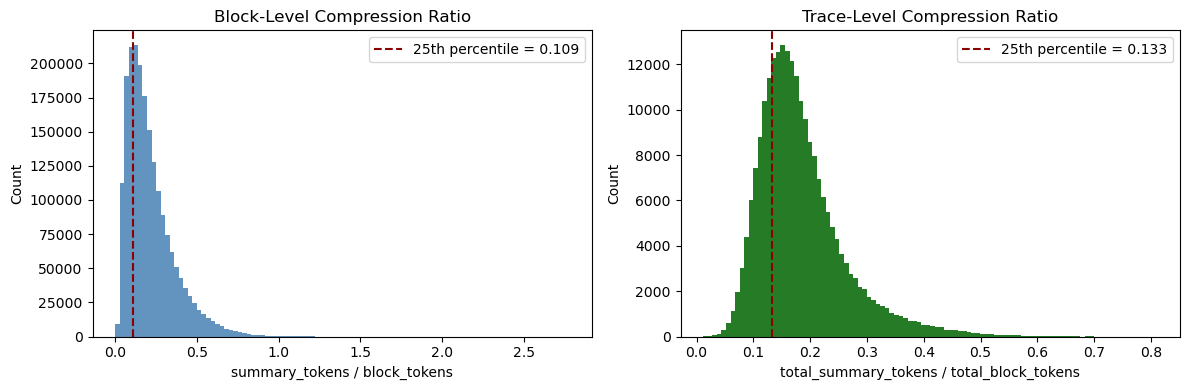

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_model_blocks["summary_to_block_token_ratio"],
    bins=100,
    color="steelblue",
    alpha=0.85,
)

axes[0].axvline(
    block_threshold,
    color="darkred",
    linestyle="--",
    label=f"25th percentile = {block_threshold:.3f}",
)

axes[0].set_title("Block-Level Compression Ratio")
axes[0].set_xlabel("summary_tokens / block_tokens")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(
    df_model_traces["trace_total_summary_to_block_token_ratio"],
    bins=100,
    color="darkgreen",
    alpha=0.85,
)

axes[1].axvline(
    trace_threshold,
    color="darkred",
    linestyle="--",
    label=f"25th percentile = {trace_threshold:.3f}",
)

axes[1].set_title("Trace-Level Compression Ratio")
axes[1].set_xlabel("total_summary_tokens / total_block_tokens")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

The block-level and trace-level distributions both show that summaries are usually much shorter than the original reasoning blocks. The median block-level compression ratio is below 0.20, meaning that a typical summary contains less than one fifth of the original block’s tokens.

These distributions also show why the classification task is meaningful. Compression is not constant across blocks or traces: some reasoning segments are compressed much more aggressively than others.

# 5. Compression Evolution

The previous section defined compression at the block and trace level. This section asks whether compression changes systematically as a reasoning trace unfolds.

The main metric is still:

`summary_to_block_token_ratio`

Lower values indicate stronger compression. Higher values indicate weaker compression.

We examine compression evolution in two ways:

1. by absolute block index, such as block 0, block 1, block 2
2. by relative position in the trace, where 0 is the first block and 1 is the final block

Relative position is useful because traces have different numbers of blocks.

In [24]:
compression_by_block_index = (
    df_model_blocks
    .groupby("block_index")
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        median_ratio=("summary_to_block_token_ratio", "median"),
        mean_savings=("token_compression_savings", "mean"),
        median_savings=("token_compression_savings", "median"),
    )
    .reset_index()
)

compression_by_block_index.head(10).round(4)

,block_index,n_blocks,mean_ratio,median_ratio,mean_savings,median_savings
0,0,228557,0.1644,0.1313,0.8356,0.8687
1,1,228458,0.1796,0.1448,0.8204,0.8552
2,2,227420,0.1947,0.1591,0.8053,0.8409
3,3,223045,0.2049,0.1687,0.7951,0.8313
4,4,215013,0.2138,0.1774,0.7862,0.8226
5,5,201169,0.2223,0.1857,0.7777,0.8143
6,6,179205,0.2315,0.1951,0.7685,0.8049
7,7,149654,0.2413,0.2052,0.7587,0.7948
8,8,117163,0.2513,0.2156,0.7487,0.7844
9,9,86277,0.2614,0.2266,0.7386,0.7734


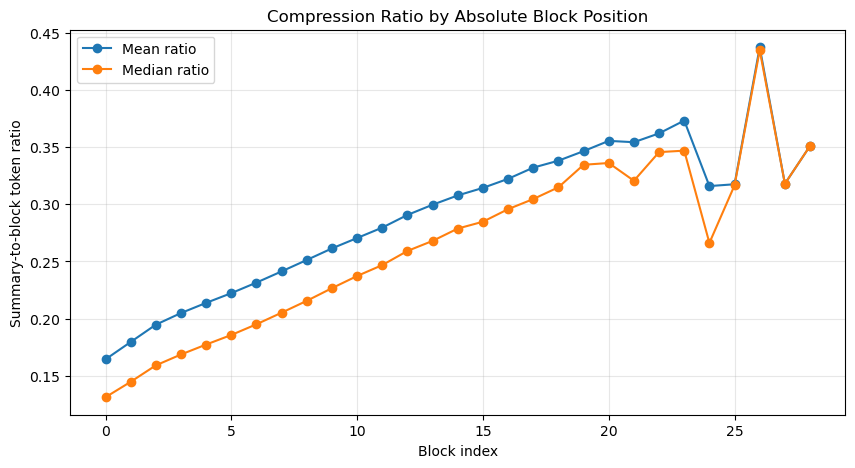

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["mean_ratio"],
    marker="o",
    label="Mean ratio",
)

ax.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["median_ratio"],
    marker="o",
    label="Median ratio",
)

ax.set_xlabel("Block index")
ax.set_ylabel("Summary-to-block token ratio")
ax.set_title("Compression Ratio by Absolute Block Position")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [26]:
df_blocks_position = df_model_blocks.copy()

df_blocks_position["relative_position_bin"] = pd.cut(
    df_blocks_position["relative_block_position"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

In [27]:
compression_by_relative_position = (
    df_blocks_position
    .groupby("relative_position_bin", observed=True)
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        std_ratio=("summary_to_block_token_ratio", "std"),
        median_ratio=("summary_to_block_token_ratio", "median"),
        mean_savings=("token_compression_savings", "mean"),
        median_savings=("token_compression_savings", "median"),
    )
    .reset_index()
)

compression_by_relative_position["se_ratio"] = (
    compression_by_relative_position["std_ratio"]
    / np.sqrt(compression_by_relative_position["n_blocks"])
)

compression_by_relative_position["position_midpoint"] = (
    compression_by_relative_position["relative_position_bin"]
    .apply(lambda interval: interval.mid)
    .astype(float)
)

compression_by_relative_position.round(4)

,relative_position_bin,n_blocks,mean_ratio,std_ratio,median_ratio,mean_savings,median_savings,se_ratio,position_midpoint
0,"(-0.001, 0.1]",288524,0.1678,0.1163,0.1358,0.8322,0.8642,0.0002,0.0495
1,"(0.1, 0.2]",206026,0.1795,0.1252,0.1467,0.8205,0.8533,0.0003,0.1500
2,"(0.2, 0.3]",168741,0.1975,0.1328,0.1644,0.8025,0.8356,0.0003,0.2500
3,"(0.3, 0.4]",187115,0.2079,0.1395,0.1736,0.7921,0.8264,0.0003,0.3500
4,"(0.4, 0.5]",213684,0.2171,0.1444,0.1820,0.7829,0.8180,0.0003,0.4500
5,"(0.5, 0.6]",143965,0.2258,0.1471,0.1911,0.7742,0.8089,0.0004,0.5500
6,"(0.6, 0.7]",162970,0.2363,0.1523,0.2007,0.7637,0.7993,0.0004,0.6500
7,"(0.7, 0.8]",192886,0.2395,0.1562,0.2028,0.7605,0.7972,0.0004,0.7500
8,"(0.8, 0.9]",181881,0.2455,0.1603,0.2072,0.7545,0.7928,0.0004,0.8500
9,"(0.9, 1.0]",267718,0.2532,0.1692,0.2143,0.7468,0.7857,0.0003,0.9500


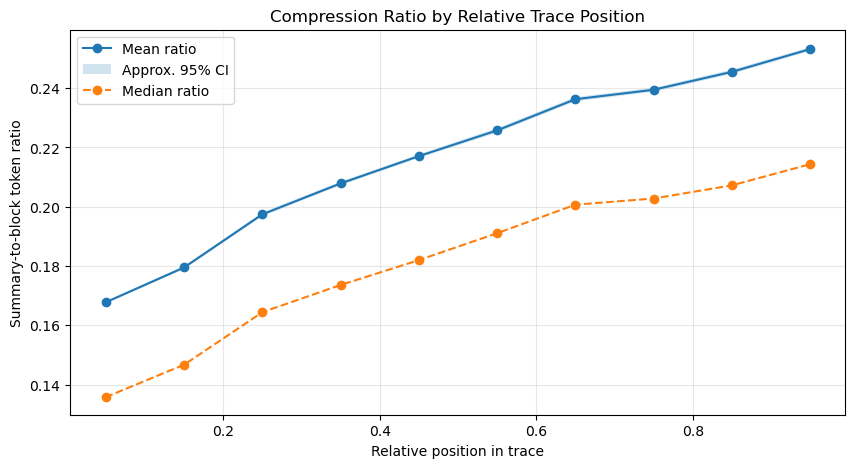

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

x = compression_by_relative_position["position_midpoint"]
y = compression_by_relative_position["mean_ratio"]
se = compression_by_relative_position["se_ratio"]

ax.plot(
    x,
    y,
    marker="o",
    label="Mean ratio",
)

ax.fill_between(
    x,
    y - 1.96 * se,
    y + 1.96 * se,
    alpha=0.2,
    label="Approx. 95% CI",
)

ax.plot(
    compression_by_relative_position["position_midpoint"],
    compression_by_relative_position["median_ratio"],
    marker="o",
    linestyle="--",
    label="Median ratio",
)

ax.set_xlabel("Relative position in trace")
ax.set_ylabel("Summary-to-block token ratio")
ax.set_title("Compression Ratio by Relative Trace Position")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

Both views show that compression changes over the reasoning trajectory.

The relative-position plot gives the clearest pattern: the average compression ratio increases as traces progress from early to late blocks. Since lower ratios mean stronger compression, this suggests that earlier reasoning blocks are compressed more aggressively, while later blocks are less compressed.

The absolute block-index plot is more irregular at high block indices because fewer traces contain many blocks. Those later-index estimates are based on fewer observations and are therefore noisier.

This pattern suggests that reasoning traces are not homogeneous. Early blocks may contain more exploratory, redundant, or scaffold-like reasoning, while later blocks may be more concise, answer-directed, or information-dense.

This motivates the sequential modeling setup used later in the notebook. If compression changes over the trajectory, then prediction should account not only for the current block, but also for where the block appears and what has happened previously in the trace.

# 6. Modeling Results

This section summarizes the main predictive modeling experiments.

The project evaluates three related prediction tasks:

1. **Block-level prediction**

   Predict whether a block-summary pair is highly compressed using current block features, problem features, and metadata.

2. **Trace-level prediction**

   Predict whether an entire reasoning trace is highly compressed using only problem features and metadata.

3. **Sequential block-level prediction**

   Predict whether the current summary is highly compressed using the problem, current block, and prior compression history from earlier blocks in the same trace.

The models are evaluated with accuracy, balanced accuracy, and ROC AUC. Balanced accuracy and ROC AUC are the most informative metrics because the compression targets are imbalanced.

In [ ]:
all_model_results = pd.read_parquet(
    FULL_BUILD_DIR / "model_results_summary.parquet"
)

In [34]:
model_results = all_model_results.copy()
model_results_display = model_results.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    model_results_display[col] = (
        model_results_display[col] * 100
    ).round(2)

model_results_display

,task,feature_set,model,accuracy,balanced_accuracy,roc_auc
0,Block-level,Current block + problem + metadata,Dummy,75.67,50.00,NaN
1,Block-level,Current block + problem + metadata,Logistic regression,73.70,72.17,79.81
2,Block-level,Current block + problem + metadata,Random forest,76.70,71.52,80.20
3,Block-level,Current block + problem + metadata,Gradient boosting,72.86,72.73,80.78
4,Trace-level,Problem + metadata only,Dummy,77.47,50.00,NaN
5,Trace-level,Problem + metadata only,Logistic regression,45.64,54.23,54.48
6,Trace-level,Problem + metadata only,Random forest,62.88,61.94,67.54
7,Trace-level,Problem + metadata only,Gradient boosting,60.15,61.06,65.97
8,First-block sequential,Problem + first block + metadata,Random forest,73.27,73.10,81.60
9,First-block sequential,Problem + first block + metadata,Gradient boosting,73.18,73.41,81.85


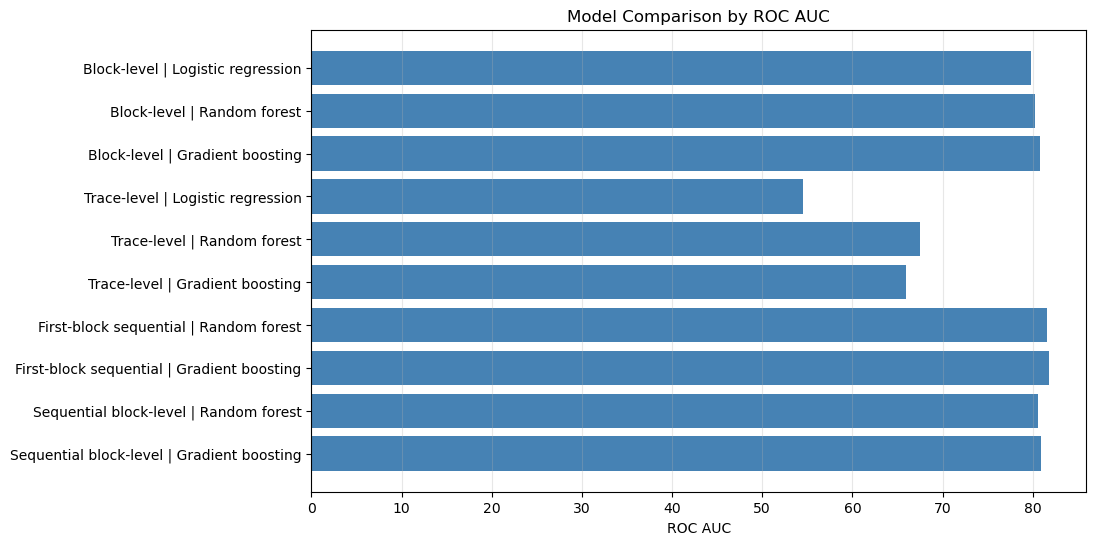

In [31]:
plot_results = model_results.dropna(subset=["roc_auc"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

plot_labels = (
    plot_results["task"]
    + " | "
    + plot_results["model"]
)

ax.barh(
    plot_labels,
    plot_results["roc_auc"],
    color="steelblue",
)

ax.set_xlabel("ROC AUC")
ax.set_title("Model Comparison by ROC AUC")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)

plt.show()

## Main Findings

The block-level models perform substantially better than the dummy baseline. Logistic regression, random forest, and gradient boosting all reach ROC AUC around 80, showing that block-level compressibility is predictable from the engineered features.

Trace-level prediction from problem features alone is much harder. The best trace-level model reaches ROC AUC around 68, suggesting that the original problem contains some signal about overall trace compressibility, but not enough to strongly determine it.

The first-block sequential models perform strongly, with ROC AUC above 81. This shows that once the first reasoning block is observed, the model can predict the compression behavior of the first summary much more effectively than from the problem alone.

The full sequential block-level models perform similarly to the block-level models, with a small improvement for gradient boosting. This suggests that prior compression history adds some information, but the current reasoning block remains the dominant predictor.

## Interpretation Across Tasks

The modeling results suggest a hierarchy of predictability.

Problem-only trace-level prediction is the weakest task. This means that compressibility is not determined primarily by the prompt alone.

Block-level prediction is much stronger. Once the current reasoning block is observed, its length and structural properties provide substantial information about how compressed its summary will be.

Sequential models add information about the previous trajectory of the trace. The gains are modest, but they support the idea that compression is partly trajectory-dependent rather than purely local.

Overall, the results indicate that reasoning compressibility is an emergent property of the generated reasoning process. It is partly shaped by the original problem, but much more strongly revealed by the reasoning blocks themselves.

# 7. Sequential Modeling Insight

The sequential models ask a more dynamic question than the static block-level models.

Instead of treating each block-summary pair as fully independent, the sequential setup uses information from the reasoning trajectory before the current summary is observed. For each block `t`, the model predicts whether `summary_t` will be highly compressed using:

- the original problem features,
- metadata,
- the current reasoning block,
- previous block and summary statistics,
- cumulative compression behavior before block `t`.

This setup is closer to an online compression setting, where a system observes reasoning as it unfolds and decides how compressible the next state is likely to be.

In [36]:
sequential_results_display = sequential_results.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    sequential_results_display[col] = (
        sequential_results_display[col] * 100
    ).round(2)

sequential_results_display

,task,feature_set,model,accuracy,balanced_accuracy,roc_auc
8,First-block sequential,Problem + first block + metadata,Random forest,73.27,73.10,81.60
9,First-block sequential,Problem + first block + metadata,Gradient boosting,73.18,73.41,81.85
10,Sequential block-level,Problem + current block + prior history + meta...,Random forest,76.13,72.06,80.61
11,Sequential block-level,Problem + current block + prior history + meta...,Gradient boosting,72.73,72.77,80.93


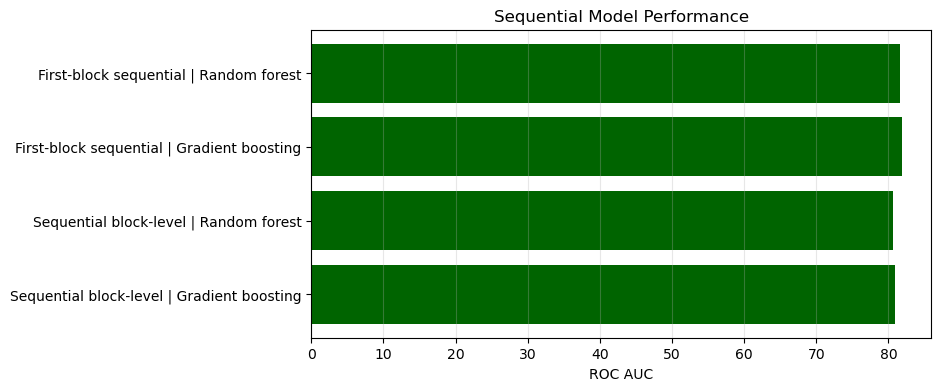

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

seq_plot = sequential_results_display.dropna(subset=["roc_auc"]).copy()

labels = seq_plot["task"] + " | " + seq_plot["model"]

ax.barh(
    labels,
    seq_plot["roc_auc"],
    color="darkgreen",
)

ax.set_xlabel("ROC AUC")
ax.set_title("Sequential Model Performance")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)

plt.show()

In [ ]:
seq_rf_importance_by_family = pd.read_parquet(
    FULL_BUILD_DIR / "seq_rf_importance_by_family.parquet"
)
seq_gb_permutation_by_family = pd.read_parquet(
    FULL_BUILD_DIR / "seq_gb_permutation_by_family.parquet"
)

In [40]:
seq_gb_permutation_by_family_display = seq_gb_permutation_by_family.copy()

seq_gb_permutation_by_family_display["importance_share_pct"] = (
    seq_gb_permutation_by_family_display["total_importance"]
    / seq_gb_permutation_by_family_display["total_importance"].sum()
    * 100
).round(2)

seq_gb_permutation_by_family_display

,feature_family,total_importance,importance_share_pct
0,current_block,0.237656,88.17
1,history,0.028830,10.70
3,problem,0.002317,0.86
2,metadata,0.000728,0.27


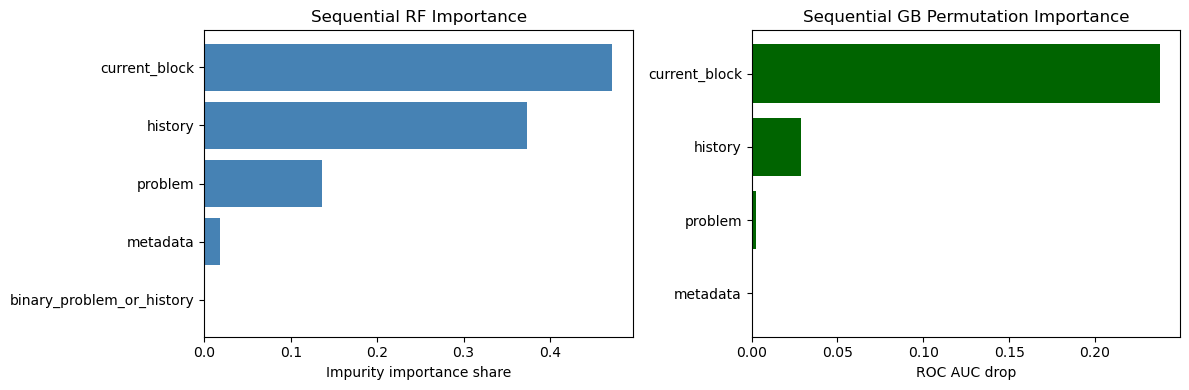

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rf_plot = seq_rf_importance_by_family.sort_values("total_importance")
axes[0].barh(
    rf_plot["feature_family"],
    rf_plot["total_importance"],
    color="steelblue",
)
axes[0].set_title("Sequential RF Importance")
axes[0].set_xlabel("Impurity importance share")

gb_plot = seq_gb_permutation_by_family.sort_values("total_importance")
axes[1].barh(
    gb_plot["feature_family"],
    gb_plot["total_importance"],
    color="darkgreen",
)
axes[1].set_title("Sequential GB Permutation Importance")
axes[1].set_xlabel("ROC AUC drop")

plt.tight_layout()
plt.show()

### Sequential Interpretation

The sequential models perform similarly to the strongest block-level models, with ROC AUC around 81. This confirms that compression can be predicted in an online-like setting using the current block and prior trace history.

The feature-family diagnostics show that the current block remains the dominant predictor. This is especially clear in the gradient boosting permutation importance, where shuffling current-block features causes the largest drop in ROC AUC.

History features also matter, but their role is more model-dependent. The random forest assigns substantial impurity-based importance to history features, while gradient boosting permutation importance suggests that history contributes a smaller incremental performance gain once the current block is known.

This suggests that compression is partly sequential, but strongly local. The previous trajectory of the reasoning trace provides useful context, yet the current reasoning block contains most of the directly predictive information about the compression of its corresponding summary.

The result is consistent with the compression-evolution plot: compression changes over the course of a trace, but the local content and size of each reasoning block remain central. A future extension could add semantic features or embeddings of current and previous blocks to capture trajectory information beyond token counts and simple cumulative statistics.

# 8. Interpretation

## Epistemic Interpretation

This project began with a practical question: can the compressibility of chain-of-thought reasoning traces be measured and predicted?

The answer from the current analysis is yes, but with an important qualification. Compressibility is not strongly determined by the problem alone. Trace-level models that use only problem features have limited predictive power. Once the generated reasoning block is observed, however, compressibility becomes much more predictable.

This suggests that compression is an emergent property of the reasoning process itself. The prompt creates the conditions for a reasoning trajectory, but the actual compressibility of that trajectory is revealed in the generated reasoning blocks.

## Compression as Structure

Compression is possible only when there is structure to exploit.

A random sequence is incompressible because it has no regularities that can be used to produce a shorter representation. If a sequence can be compressed, then some part of it is predictable from some other part, from the broader context, or from a learned model of the domain.

The results here show that reasoning traces are not random streams. Block-level compression is predictable with ROC AUC around 80-82, which implies that the traces contain systematic regularities. Some reasoning blocks contain more redundancy, scaffolding, or summarizable structure than others.

In this sense, compressibility becomes an empirical signal of structure inside the reasoning process.

## Prediction and Compression

Prediction and compression are deeply connected.

To compress a reasoning block is to identify what can be preserved in shorter form and what can be omitted without losing the relevant state. To predict compressibility is to anticipate how much of a block is redundant or structurally recoverable before seeing the summary.

The sequential models make this connection explicit. They ask whether the current block and the previous compression trajectory can predict the compression behavior of the current summary. The answer is partly yes: current-block features dominate, but prior history contributes additional signal.

This points toward a view of reasoning traces as evolving information states. At each step, some content is new, some content is repeated, and some content functions as temporary scaffolding for the generation process.

## Compression and Intelligence

Intelligence can be understood, in part, as the ability to discover useful structure.

A system that reasons well does not merely store every intermediate token. It identifies abstractions, preserves relevant state, discards redundant detail, and carries forward information needed for future inference.

The MEMENTO-style setup is interesting because it makes this state-management problem visible. Each block-summary pair is a small experiment in what can be compressed while preserving forward usefulness.

The findings here suggest that chain-of-thought traces are neither pure noise nor perfectly dense information. They occupy a middle ground: they contain meaningful reasoning, but also systematic redundancy. That redundancy can be measured and predicted.

## What This Repository Shows

This repository builds a full pipeline for studying reasoning under compression:

- streaming and parsing OpenMementos,
- engineering block-level and trace-level compression features,
- defining token-based compression targets,
- modeling block-level and trace-level compressibility,
- analyzing compression evolution across reasoning traces,
- testing sequential predictors that use prior trace history.

The main empirical findings are:

1. Block-level compressibility is predictable once the current reasoning block is observed.
2. Problem-only trace-level compressibility is much harder to predict.
3. Compression tends to weaken later in the reasoning trace.
4. Sequential history provides some signal, but the current block remains the dominant predictor.
5. Reasoning traces contain systematic redundancy rather than random incompressible noise.

## Open Direction

The next step is to move beyond token-count features.

The current models mostly see length, position, metadata, and simple history. They do not yet understand the semantic content of the reasoning blocks. A richer model could add block embeddings, semantic similarity between blocks and summaries, discourse features, or task-specific correctness signals.

That would move the project from predicting how much text is compressed toward understanding what kind of reasoning content is compressible.

The deeper question is not simply whether reasoning can be shortened. It is which parts of reasoning are temporary scaffolding, which parts are durable state, and how intelligent systems can learn the difference.